#  Phoneme Distribution Across Languages
**Dataset:** PHOIBLE 2.0 — 2,186 languages, 3,183 phoneme types

### Table of Contents
1. Setup & Data Loading
2. Dataset Overview & EDA
3. Universal Phonemes — Most Common Across Languages
4. Phoneme Inventory Size Distribution
5. Vowel vs Consonant Analysis
6. Language Family Comparison
7. Tone Languages Analysis
8. Geographic Patterns
9. Rare vs Common Phonemes
10. Clustering Languages by Phoneme Inventory
11. South Asian Languages Deep Dive
12. Key Insights & Conclusions

## 1. Setup & Data Loading

In [15]:
# Install dependencies 
# !pip install pandas matplotlib seaborn numpy scipy scikit-learn requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')



In [16]:
#  Download PHOIBLE dataset 
# Option 1: Direct download from GitHub
PHOIBLE_URL = 'https://raw.githubusercontent.com/phoible/dev/master/data/phoible.csv'

try:
    df = pd.read_csv(PHOIBLE_URL, low_memory=False)
    print(f' Downloaded from GitHub — {df.shape[0]:,} rows, {df.shape[1]} columns')
except Exception as e:
    # Option 2: Load from local file if already downloaded
    print(f'Network error: {e}')
    print('Loading from local file: phoible.csv')
    df = pd.read_csv('phoible.csv', low_memory=False)
    print(f' Loaded locally — {df.shape[0]:,} rows, {df.shape[1]} columns')

 Downloaded from GitHub — 105,484 rows, 49 columns


In [17]:
print('COLUMNS')
print(df.columns.tolist())
print()
print(' FIRST 5 ROWS')
df.head()

COLUMNS
['InventoryID', 'Glottocode', 'ISO6393', 'LanguageName', 'SpecificDialect', 'GlyphID', 'Phoneme', 'Allophones', 'Marginal', 'SegmentClass', 'Source', 'tone', 'stress', 'syllabic', 'short', 'long', 'consonantal', 'sonorant', 'continuant', 'delayedRelease', 'approximant', 'tap', 'trill', 'nasal', 'lateral', 'labial', 'round', 'labiodental', 'coronal', 'anterior', 'distributed', 'strident', 'dorsal', 'high', 'low', 'front', 'back', 'tense', 'retractedTongueRoot', 'advancedTongueRoot', 'periodicGlottalSource', 'epilaryngealSource', 'spreadGlottis', 'constrictedGlottis', 'fortis', 'lenis', 'raisedLarynxEjective', 'loweredLarynxImplosive', 'click']

 FIRST 5 ROWS


,InventoryID,Glottocode,ISO6393,LanguageName,SpecificDialect,GlyphID,Phoneme,Allophones,Marginal,SegmentClass,...,advancedTongueRoot,periodicGlottalSource,epilaryngealSource,spreadGlottis,constrictedGlottis,fortis,lenis,raisedLarynxEjective,loweredLarynxImplosive,click
0,1,kore1280,kor,Korean,NaN,0068,h,ç h ɦ,NaN,consonant,...,-,-,-,+,-,-,-,-,-,-
1,1,kore1280,kor,Korean,NaN,006A,j,j,NaN,consonant,...,-,+,-,-,-,-,-,-,-,-
2,1,kore1280,kor,Korean,NaN,006B,k,k̚ ɡ k,NaN,consonant,...,-,-,-,-,-,-,-,-,-,-
3,1,kore1280,kor,Korean,NaN,006B+02B0,kʰ,kʰ,NaN,consonant,...,-,-,-,+,-,-,-,-,-,-
4,1,kore1280,kor,Korean,NaN,006B+02C0,kˀ,kˀ,NaN,consonant,...,-,-,-,-,+,-,-,-,-,-


In [18]:
# Basic info
print(' DATASET SUMMARY ')
print(f'Total rows          : {len(df):,}')
print(f'Total languages     : {df["LanguageName"].nunique():,}')
print(f'Unique phonemes     : {df["Phoneme"].nunique():,}')
print(f'Language families   : {df["family_id"].nunique() if "family_id" in df.columns else "N/A"}')
print()
print(' NULL VALUES ')
print(df.isnull().sum()[df.isnull().sum() > 0])

 DATASET SUMMARY 
Total rows          : 105,484
Total languages     : 2,716
Unique phonemes     : 3,142
Language families   : N/A

 NULL VALUES 
Glottocode            19
ISO6393               25
SpecificDialect    83499
Allophones         53580
Marginal           20874
dtype: int64


## 2. Dataset Overview & EDA

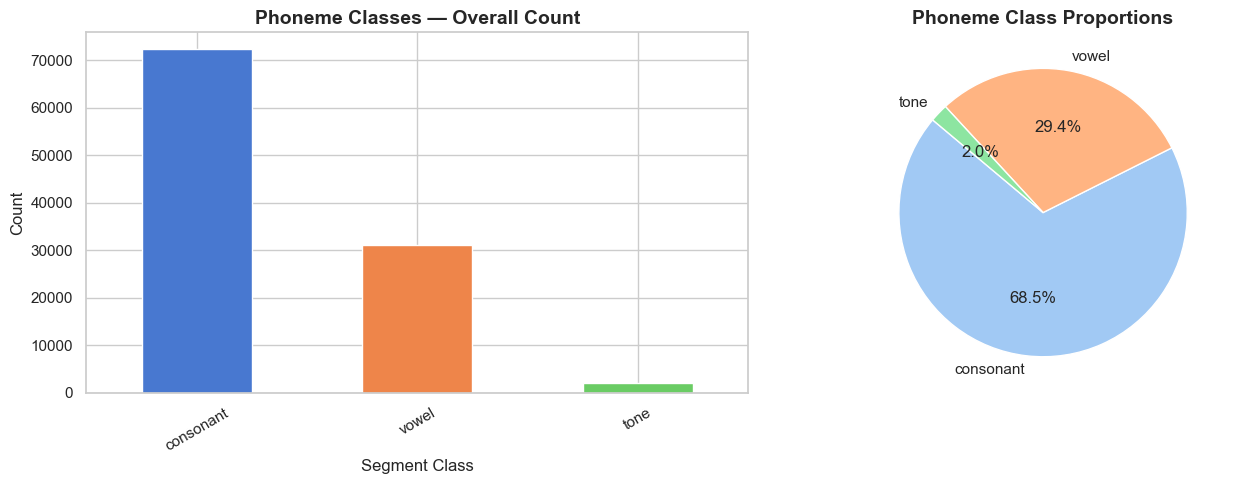

SegmentClass
consonant    72282
vowel        31052
tone          2150
Name: count, dtype: int64


In [34]:
#  Phoneme class distribution 
if 'SegmentClass' in df.columns:
    class_counts = df['SegmentClass'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    class_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'), edgecolor='white')
    axes[0].set_title('Phoneme Classes — Overall Count', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Segment Class')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    
    # Pie chart
    axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('pastel'), startangle=140)
    axes[1].set_title('Phoneme Class Proportions', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('phoneme_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(class_counts)

## 3. Universal Phonemes — Most Common Across Languages

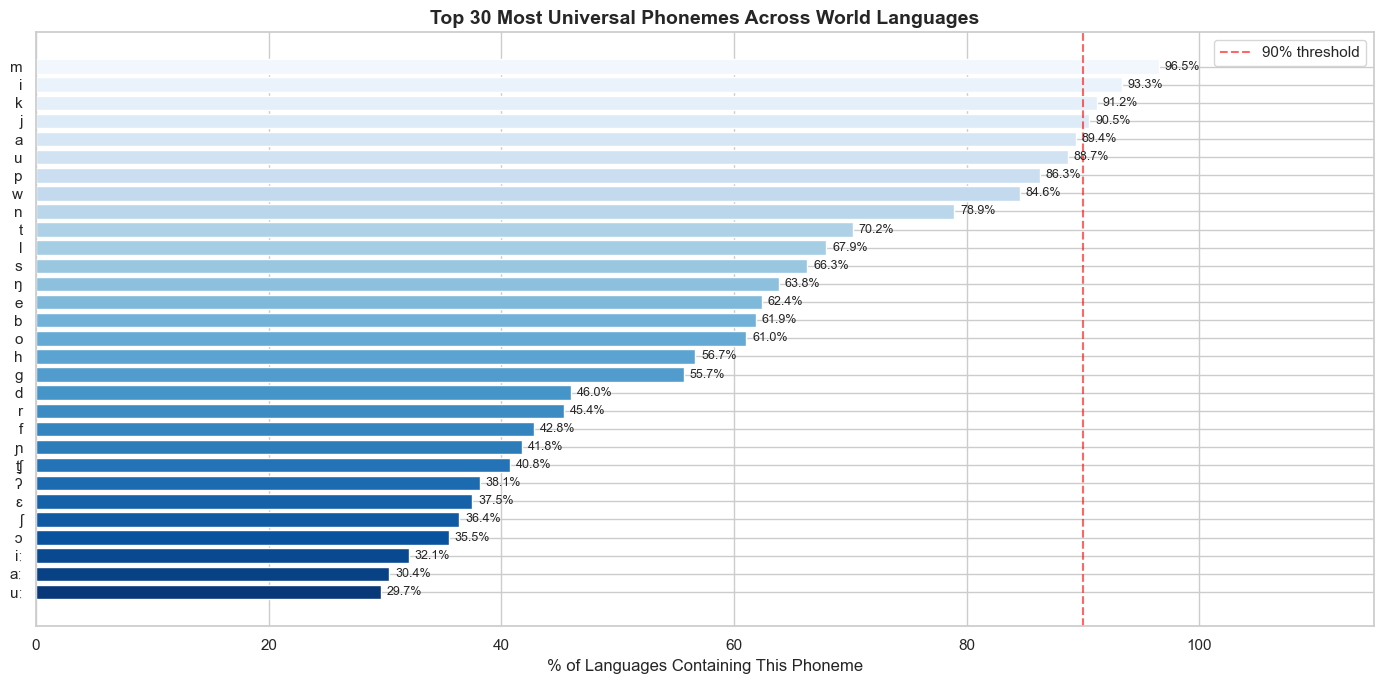


Top 10 Universal Phonemes:
Phoneme  Language_Count  Percentage
      m            2621       96.50
      i            2534       93.30
      k            2477       91.20
      j            2459       90.54
      a            2427       89.36
      u            2409       88.70
      p            2343       86.27
      w            2297       84.57
      n            2144       78.94
      t            1907       70.21


In [20]:
#  Top 30 most universal phonemes 
total_languages = df['LanguageName'].nunique()

phoneme_freq = (
    df.groupby('Phoneme')['LanguageName']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
phoneme_freq.columns = ['Phoneme', 'Language_Count']
phoneme_freq['Percentage'] = (phoneme_freq['Language_Count'] / total_languages * 100).round(2)

top30 = phoneme_freq.head(30)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top30['Phoneme'][::-1], top30['Percentage'][::-1],
               color=sns.color_palette('Blues_r', 30), edgecolor='white')

# Add value labels
for bar, pct in zip(bars, top30['Percentage'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_xlabel('% of Languages Containing This Phoneme', fontsize=12)
ax.set_title('Top 30 Most Universal Phonemes Across World Languages', fontsize=14, fontweight='bold')
ax.set_xlim(0, 115)
ax.axvline(x=90, color='red', linestyle='--', alpha=0.6, label='90% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('universal_phonemes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Universal Phonemes:')
print(top30.head(10).to_string(index=False))

## 4. Phoneme Inventory Size Distribution

 INVENTORY SIZE STATS 
count    2716.00
mean       35.57
std        15.10
min        11.00
25%        25.00
50%        32.00
75%        43.00
max       161.00
Name: Inventory_Size, dtype: float64


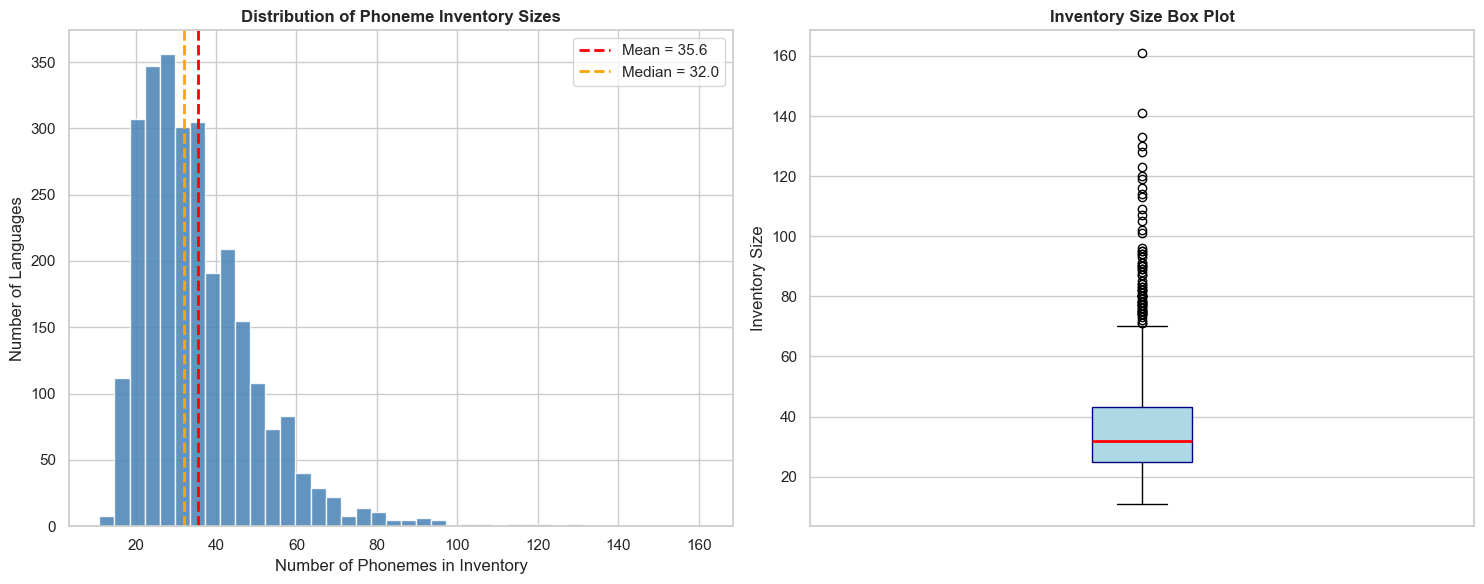


 Languages with LARGEST inventories:
      Language  Inventory_Size
        !Xóõ             161
           !XU             141
Soghpo Tibetan             133
       Bengali             130
  Kildin Saami             128
        Mbembe             123
          !Xun             120
         Hindi             119
       Lezgian             116
         Dutch             114

 Languages with SMALLEST inventories:
Language  Inventory_Size
  PIRAHA              11
  Pirahã              11
 ROTOKAS              11
HAWAIIAN              13
  NASIOI              13
    Abau              14
    RORO              14
 TAORIPI              14
   EKARI              15
  GADSUP              15


In [21]:
#  Inventory size per language 
inventory_size = (
    df.groupby('LanguageName')['Phoneme']
    .nunique()
    .reset_index()
)
inventory_size.columns = ['Language', 'Inventory_Size']

print(' INVENTORY SIZE STATS ')
print(inventory_size['Inventory_Size'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
axes[0].hist(inventory_size['Inventory_Size'], bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(inventory_size['Inventory_Size'].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Mean = {inventory_size["Inventory_Size"].mean():.1f}')
axes[0].axvline(inventory_size['Inventory_Size'].median(), color='orange',
                linestyle='--', linewidth=2, label=f'Median = {inventory_size["Inventory_Size"].median():.1f}')
axes[0].set_xlabel('Number of Phonemes in Inventory')
axes[0].set_ylabel('Number of Languages')
axes[0].set_title('Distribution of Phoneme Inventory Sizes', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot(inventory_size['Inventory_Size'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Inventory Size')
axes[1].set_title('Inventory Size Box Plot', fontweight='bold')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('inventory_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Top & bottom
print('\n Languages with LARGEST inventories:')
print(inventory_size.nlargest(10, 'Inventory_Size').to_string(index=False))
print('\n Languages with SMALLEST inventories:')
print(inventory_size.nsmallest(10, 'Inventory_Size').to_string(index=False))

## 5. Vowel vs Consonant Analysis

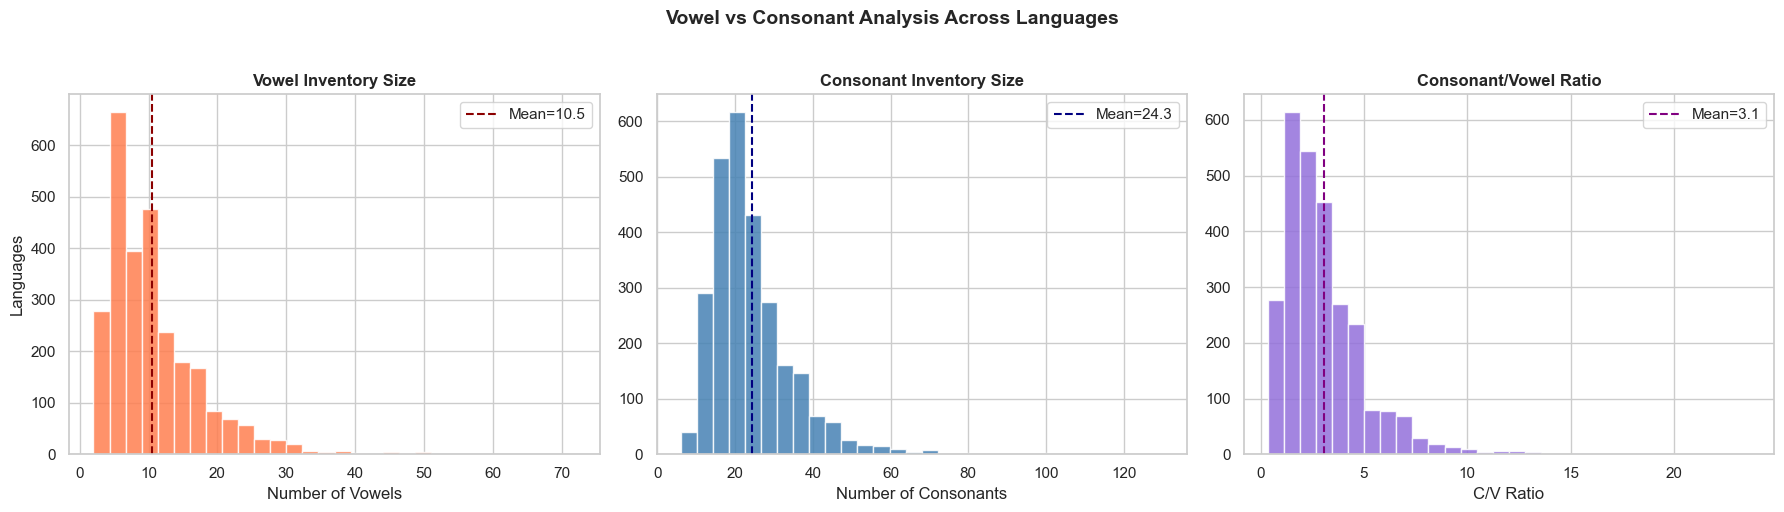


 STATS
SegmentClass    vowel  consonant  CV_Ratio
count         2716.00    2716.00   2716.00
mean            10.54      24.26      3.06
std              6.93      11.23      2.09
min              2.00       6.00      0.35
25%              6.00      17.00      1.64
50%              9.00      22.00      2.57
75%             13.00      28.00      3.83
max             72.00     130.00     23.67

 Highest C/V Ratio (consonant-heavy):
    LanguageName  vowel  consonant  CV_Ratio
Tashlhiyt Berber      3         71     23.67
          Abkhaz      3         68     22.67
           Buwal      2         38     19.00
          Adyghe      3         56     18.67
 Moroccan Arabic      4         74     18.50

 Lowest C/V Ratio (vowel-heavy):
LanguageName  vowel  consonant  CV_Ratio
       Krahô     34         12      0.35
     Apinaye     35         14      0.40
          So     50         22      0.44
      Andoke     24         11      0.46
   Binandere     24         11      0.46


In [35]:
# ── Vowel / Consonant ratio per language ─────────────────────────────────────
if 'SegmentClass' in df.columns:
    vc_counts = (
        df.groupby(['LanguageName', 'SegmentClass'])['Phoneme']
        .nunique()
        .unstack(fill_value=0)
        .reset_index()
    )

    # Keep only languages with both consonants and vowels
    if 'consonant' in vc_counts.columns and 'vowel' in vc_counts.columns:
        vc_counts = vc_counts[(vc_counts['consonant'] > 0) & (vc_counts['vowel'] > 0)].copy()
        vc_counts['CV_Ratio'] = (vc_counts['consonant'] / vc_counts['vowel']).round(2)
        vc_counts['Total'] = vc_counts['consonant'] + vc_counts['vowel']

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Vowel distribution
        axes[0].hist(vc_counts['vowel'], bins=30, color='coral', edgecolor='white', alpha=0.85)
        axes[0].set_title('Vowel Inventory Size', fontweight='bold')
        axes[0].set_xlabel('Number of Vowels')
        axes[0].set_ylabel('Languages')
        axes[0].axvline(vc_counts['vowel'].mean(), color='darkred', linestyle='--',
                        label=f'Mean={vc_counts["vowel"].mean():.1f}')
        axes[0].legend()

        # Consonant distribution
        axes[1].hist(vc_counts['consonant'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
        axes[1].set_title('Consonant Inventory Size', fontweight='bold')
        axes[1].set_xlabel('Number of Consonants')
        axes[1].axvline(vc_counts['consonant'].mean(), color='navy', linestyle='--',
                        label=f'Mean={vc_counts["consonant"].mean():.1f}')
        axes[1].legend()

        # C/V ratio
        axes[2].hist(vc_counts['CV_Ratio'], bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
        axes[2].set_title('Consonant/Vowel Ratio', fontweight='bold')
        axes[2].set_xlabel('C/V Ratio')
        axes[2].axvline(vc_counts['CV_Ratio'].mean(), color='purple', linestyle='--',
                        label=f'Mean={vc_counts["CV_Ratio"].mean():.1f}')
        axes[2].legend()

        plt.suptitle('Vowel vs Consonant Analysis Across Languages', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('vowel_consonant_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

        print('\n STATS')
        print(vc_counts[['vowel', 'consonant', 'CV_Ratio']].describe().round(2))

        print('\n Highest C/V Ratio (consonant-heavy):')
        print(vc_counts.nlargest(5, 'CV_Ratio')[['LanguageName','vowel','consonant','CV_Ratio']].to_string(index=False))

        print('\n Lowest C/V Ratio (vowel-heavy):')
        print(vc_counts.nsmallest(5, 'CV_Ratio')[['LanguageName','vowel','consonant','CV_Ratio']].to_string(index=False))

## 6. Language Family Comparison

In [23]:
#  Average inventory size by language family
family_col = 'family_id' if 'family_id' in df.columns else ('macroarea' if 'macroarea' in df.columns else None)

if family_col:
    family_inventory = (
        df.groupby([family_col, 'LanguageName'])['Phoneme']
        .nunique()
        .reset_index()
        .groupby(family_col)['Phoneme']
        .agg(['mean', 'count', 'std'])
        .reset_index()
    )
    family_inventory.columns = [family_col, 'Avg_Inventory', 'Lang_Count', 'Std']

    # Filter families with at least 5 languages
    family_inventory = family_inventory[family_inventory['Lang_Count'] >= 5].sort_values(
        'Avg_Inventory', ascending=False
    ).head(20)

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = sns.color_palette('tab20', len(family_inventory))
    bars = ax.barh(family_inventory[family_col][::-1],
                   family_inventory['Avg_Inventory'][::-1],
                   xerr=family_inventory['Std'][::-1],
                   color=colors, edgecolor='white', alpha=0.85, capsize=4)

    # Language count labels
    for i, (_, row) in enumerate(family_inventory[::-1].iterrows()):
        ax.text(row['Avg_Inventory'] + row['Std'] + 0.3,
                i, f'n={int(row["Lang_Count"])}', va='center', fontsize=9, color='gray')

    ax.set_xlabel('Average Phoneme Inventory Size', fontsize=12)
    ax.set_title(f'Average Phoneme Inventory by {family_col} (min 5 languages)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('family_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(family_inventory.to_string(index=False))

## 7. Tone Languages Analysis

 TONE LANGUAGE SUMMARY 
Tonal languages     : 600
Non-tonal languages : 2,116
Total languages     : 2,716

 Tone-bearing phoneme counts (top 15 tonal languages):
          Language  Inventory_Size  Tone_Phonemes
        Vietnamese              64             14
             Bafut              49             10
              Buli              46             10
               Dan             102             10
              Thai              62             10
           Babungo              82              9
   Itunyoso Trique              48              9
             Nizaa              90              9
            Ticuna              53              9
             Attie              47              8
Gwandara (Cancara)              52              8
 Gwandara (Gitata)              64              8
 Gwandara (Karshi)              46              8
   Gwandara (Koro)              48              8
 Gwandara (Nimbia)              65              8

Mann-Whitney U test on inventory size

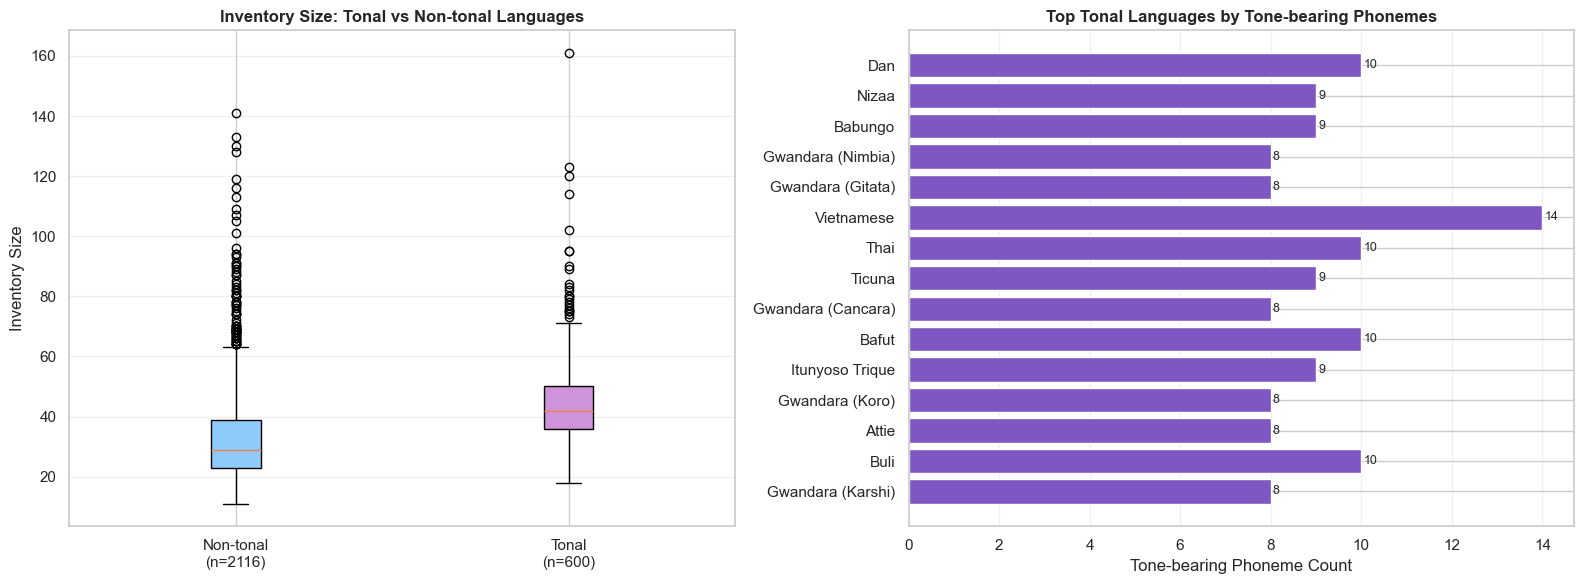

In [40]:
# ── Tone languages analysis ──────────────────────────────────────────────────
if 'tone' in df.columns:
    tone_langs = (
        df[df['tone'] == '+']
        .groupby('LanguageName')['Phoneme']
        .nunique()
        .reset_index(name='Tone_Phonemes')
    )

    tone_inventory = inventory_size.copy()
    tone_inventory['Has_Tone'] = tone_inventory['Language'].isin(tone_langs['LanguageName'])
    tone_inventory = tone_inventory.merge(
        tone_langs,
        left_on='Language',
        right_on='LanguageName',
        how='left'
    )
    tone_inventory['Tone_Phonemes'] = tone_inventory['Tone_Phonemes'].fillna(0).astype(int)

    tonal = tone_inventory[tone_inventory['Has_Tone']].copy()
    nontonal = tone_inventory[~tone_inventory['Has_Tone']].copy()

    print(' TONE LANGUAGE SUMMARY ')
    print(f'Tonal languages     : {len(tonal):,}')
    print(f'Non-tonal languages : {len(nontonal):,}')
    print(f'Total languages     : {len(tone_inventory):,}')
    print()
    print(' Tone-bearing phoneme counts (top 15 tonal languages):')
    print(tonal.nlargest(15, 'Tone_Phonemes')[['Language', 'Inventory_Size', 'Tone_Phonemes']].to_string(index=False))

    # Statistical comparison
    if len(tonal) > 0 and len(nontonal) > 0:
        from scipy.stats import mannwhitneyu
        u_stat, p_val = mannwhitneyu(tonal['Inventory_Size'], nontonal['Inventory_Size'], alternative='two-sided')
        print()
        print(f'Mann-Whitney U test on inventory size: U={u_stat:.1f}, p={p_val:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Boxplot: inventory size by tone presence
    box_data = [nontonal['Inventory_Size'], tonal['Inventory_Size']]
    bp = axes[0].boxplot(
        box_data,
        labels=[f'Non-tonal\n(n={len(nontonal)})', f'Tonal\n(n={len(tonal)})'],
        patch_artist=True
    )
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['boxes'][1].set_facecolor('#CE93D8')
    axes[0].set_ylabel('Inventory Size')
    axes[0].set_title('Inventory Size: Tonal vs Non-tonal Languages', fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')

    # Bar chart: tonal languages with most tone-bearing phonemes
    tone_top = tonal.nlargest(min(15, len(tonal)), 'Tone_Phonemes').sort_values('Inventory_Size', ascending=False)
    bars = axes[1].barh(tone_top['Language'][::-1], tone_top['Tone_Phonemes'][::-1], color='#7E57C2', edgecolor='white')
    axes[1].set_xlabel('Tone-bearing Phoneme Count')
    axes[1].set_title('Top Tonal Languages by Tone-bearing Phonemes', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, tone_top['Tone_Phonemes'][::-1]):
        axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('tone_languages_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠ No tone column found in dataset.')

## 8. Geographic / Macroarea Patterns

✅ Glottolog loaded: 27177 languages
📊 105,465 PHOIBLE records with macroarea


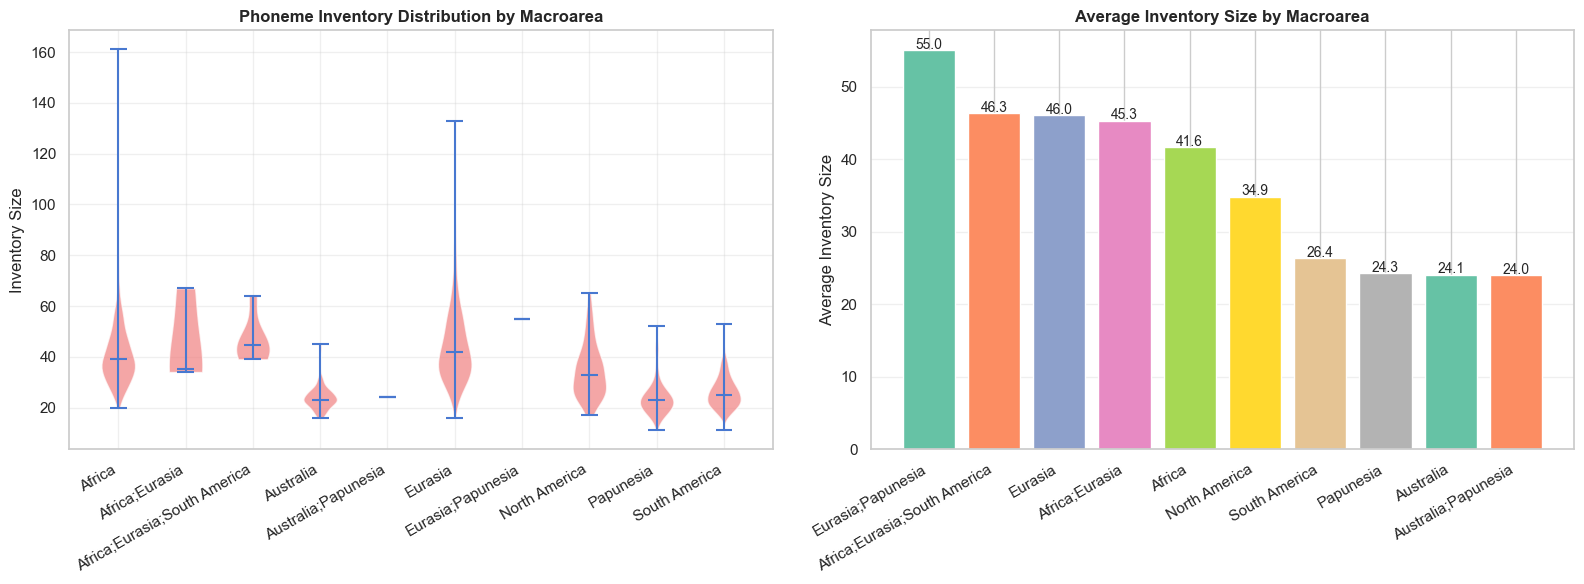


📍 Average Inventory Size by Macroarea:
Macroarea
Eurasia;Papunesia               55.000000
Africa;Eurasia;South America    46.333333
Eurasia                         46.046358
Africa;Eurasia                  45.333333
Africa                          41.637560
North America                   34.862637
South America                   26.380631
Papunesia                       24.294686
Australia                       24.100000
Australia;Papunesia             24.000000
Name: Phoneme, dtype: float64

🗺️ Language Count by Macroarea:
Macroarea
Africa                          836
Eurasia                         604
South America                   444
Australia                       430
Papunesia                       207
North America                   182
Africa;Eurasia;South America      6
Africa;Eurasia                    3
Australia;Papunesia               2
Eurasia;Papunesia                 1
Name: LanguageName, dtype: int64


In [39]:
#  Phoneme inventory by geographic macroarea (requires Glottolog data)
try:
    # Fetch Glottolog languoid data with macroarea
    glotto_url = 'https://raw.githubusercontent.com/glottolog/glottolog-cldf/master/cldf/languages.csv'
    glotto = pd.read_csv(glotto_url, low_memory=False)
    print(f'✅ Glottolog loaded: {len(glotto)} languages')
    
    # Keep relevant columns
    glotto_areas = glotto[['ID', 'Macroarea']].rename(columns={'ID': 'Glottocode'})
    
    # Merge with PHOIBLE
    df_with_area = df.merge(glotto_areas, on='Glottocode', how='left')
    
    # Filter out languages without macroarea
    df_area = df_with_area.dropna(subset=['Macroarea'])
    print(f'📊 {len(df_area):,} PHOIBLE records with macroarea')
    
    if len(df_area) > 0:
        area_inventory = (
            df_area.groupby(['Macroarea', 'LanguageName'])['Phoneme']
            .nunique()
            .reset_index()
        )
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Violin plot
        areas = area_inventory['Macroarea'].unique()
        data_by_area = [area_inventory[area_inventory['Macroarea'] == a]['Phoneme'].values for a in sorted(areas)]
        vp = axes[0].violinplot(data_by_area, showmedians=True, showmeans=False)
        for pc in vp['bodies']:
            pc.set_facecolor('lightcoral')
            pc.set_alpha(0.7)
        axes[0].set_xticks(range(1, len(areas)+1))
        axes[0].set_xticklabels(sorted(areas), rotation=30, ha='right')
        axes[0].set_ylabel('Inventory Size')
        axes[0].set_title('Phoneme Inventory Distribution by Macroarea', fontweight='bold')
        axes[0].grid(True, alpha=0.3)

        # Mean bar chart
        area_means = area_inventory.groupby('Macroarea')['Phoneme'].mean().sort_values(ascending=False)
        colors = sns.color_palette('Set2', len(area_means))
        bars = axes[1].bar(range(len(area_means)), area_means.values, color=colors, edgecolor='white')
        axes[1].set_xticks(range(len(area_means)))
        axes[1].set_xticklabels(area_means.index, rotation=30, ha='right')
        axes[1].set_ylabel('Average Inventory Size')
        axes[1].set_title('Average Inventory Size by Macroarea', fontweight='bold')
        for i, v in enumerate(area_means.values):
            axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=10)
        axes[1].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig('geographic_patterns.png', dpi=150, bbox_inches='tight')
        plt.show()

        print('\n📍 Average Inventory Size by Macroarea:')
        print(area_means)
        
        # Count languages per area
        print('\n🗺️ Language Count by Macroarea:')
        area_counts = area_inventory.groupby('Macroarea')['LanguageName'].nunique().sort_values(ascending=False)
        print(area_counts)
    else:
        print('⚠️ No languages with macroarea information found')
        
except Exception as e:
    print(f'❌ Error: {e}')
    print('⚠️ Could not fetch Glottolog data. Try running this cell again or check internet connection.')

## 9. Rare vs Common Phonemes

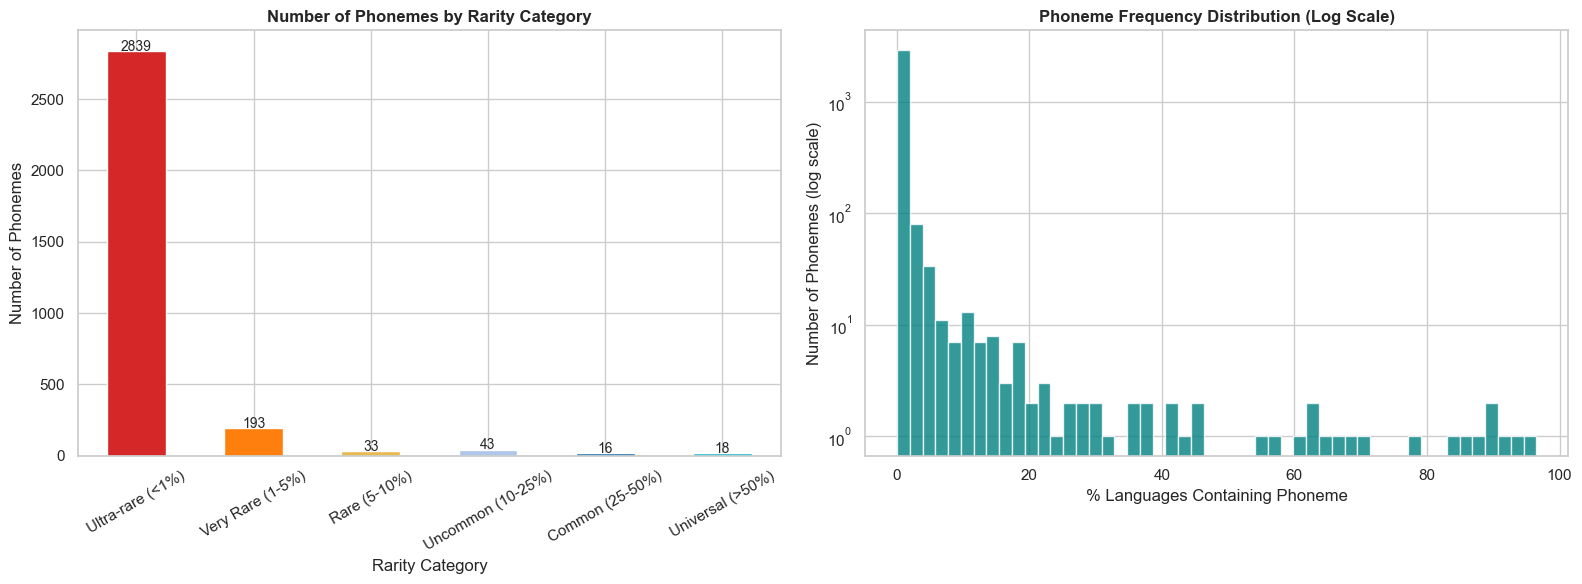

Rarity breakdown:
Rarity
Ultra-rare (<1%)     2839
Very Rare (1-5%)      193
Rare (5-10%)           33
Uncommon (10-25%)      43
Common (25-50%)        16
Universal (>50%)       18
Name: count, dtype: int64

🔴 Ultra-rare phonemes (bottom 10 by occurrence):
Phoneme  Lang_Count      Pct
     Rʲ           1 0.036819
     R̪           1 0.036819
 R̪̥|R̥           1 0.036819
   ae̞ˤ           1 0.036819
   ai̯ː           1 0.036819
   ao̞ˤ           1 0.036819
    auː           1 0.036819
    au̜           1 0.036819
     aɔ           1 0.036819
     aə           1 0.036819


In [25]:
# ── Phoneme rarity spectrum ───────────────────────────────────────────────────
phoneme_freq_full = (
    df.groupby('Phoneme')['LanguageName']
    .nunique()
    .reset_index()
)
phoneme_freq_full.columns = ['Phoneme', 'Lang_Count']
phoneme_freq_full['Pct'] = phoneme_freq_full['Lang_Count'] / total_languages * 100

# Rarity bins
bins = [0, 1, 5, 10, 25, 50, 100]
labels = ['Ultra-rare (<1%)', 'Very Rare (1-5%)', 'Rare (5-10%)',
          'Uncommon (10-25%)', 'Common (25-50%)', 'Universal (>50%)']
phoneme_freq_full['Rarity'] = pd.cut(phoneme_freq_full['Pct'], bins=bins, labels=labels, right=True)

rarity_counts = phoneme_freq_full['Rarity'].value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#d62728','#ff7f0e','#e7ba52','#aec7e8','#1f77b4','#17becf']
rarity_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Number of Phonemes by Rarity Category', fontweight='bold')
axes[0].set_xlabel('Rarity Category')
axes[0].set_ylabel('Number of Phonemes')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(rarity_counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

# Log-scale frequency distribution
axes[1].hist(phoneme_freq_full['Pct'], bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('% Languages Containing Phoneme')
axes[1].set_ylabel('Number of Phonemes (log scale)')
axes[1].set_title('Phoneme Frequency Distribution (Log Scale)', fontweight='bold')

plt.tight_layout()
plt.savefig('phoneme_rarity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rarity breakdown:')
print(rarity_counts)

print('\n🔴 Ultra-rare phonemes (bottom 10 by occurrence):')
print(phoneme_freq_full.nsmallest(10, 'Lang_Count')[['Phoneme','Lang_Count','Pct']].to_string(index=False))

## 10. Clustering Languages by Phoneme Inventory

Feature matrix shape: (2716, 50)


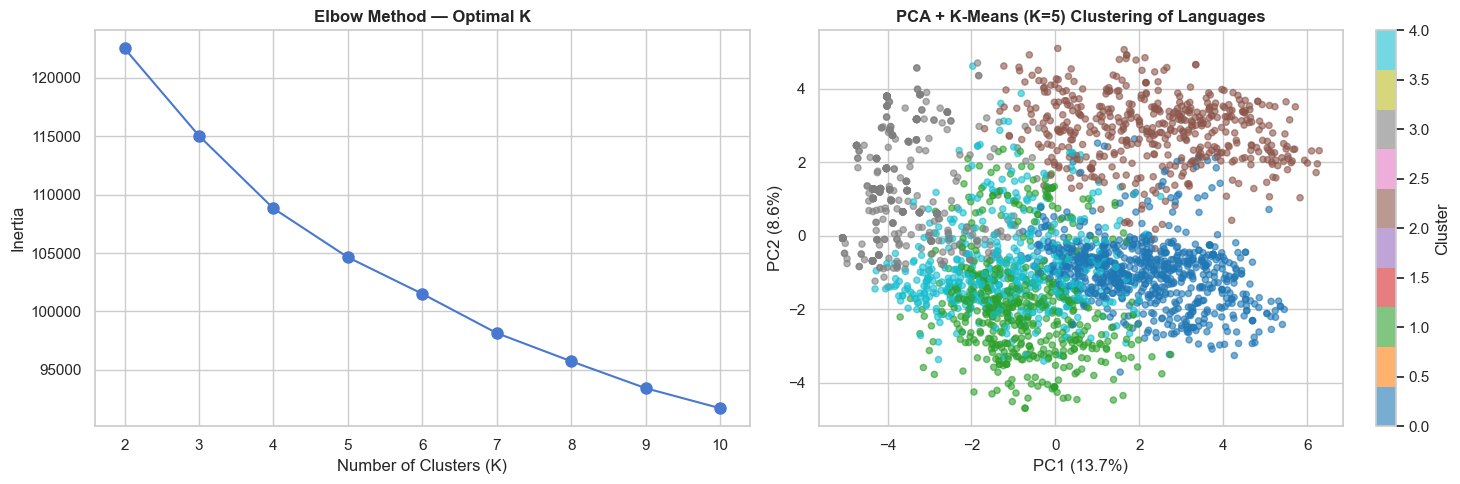


Cluster sizes:
0    726
1    527
2    486
3    499
4    478
Name: count, dtype: int64


In [26]:
# ── K-Means clustering using top phonemes as features ────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use top 50 most common phonemes as features
top_phonemes = phoneme_freq.head(50)['Phoneme'].tolist()

# Pivot: languages x phonemes (1 if present, 0 if not)
df_filtered = df[df['Phoneme'].isin(top_phonemes)]
pivot = df_filtered.pivot_table(
    index='LanguageName', columns='Phoneme',
    aggfunc='size', fill_value=0
)
pivot = (pivot > 0).astype(int)

print(f'Feature matrix shape: {pivot.shape}')

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(pivot)

# Elbow method to choose K
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xticks(list(K_range))

# PCA + K=5 clustering
K_FINAL = 5
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
clusters = km_final.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters,
                          cmap='tab10', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title(f'PCA + K-Means (K={K_FINAL}) Clustering of Languages', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('language_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster sizes
pivot['Cluster'] = clusters
print('\nCluster sizes:')
print(pd.Series(clusters).value_counts().sort_index())

## 11. South Asian Languages Deep Dive (Hindi, Urdu, Bengali, Sanskrit...)

Found 27 South Asian languages in PHOIBLE
           Language  Inventory_Size
            Bengali             130
              Hindi             119
             Sindhi             107
             Nepali             105
            Punjabi              95
             Telugu              94
         Hindi-Urdu              94
           Gujarati              87
               Urdu              84
          Malayalam              62
         HINDI-URDU              61
            Kannada              57
              Tamil              57
           Kashmiri              56
           KASHMIRI              55
            Marathi              55
           Sanskrit              45
             TELUGU              43
            BENGALI              43
          Cambodian              42
             NEPALI              39
             PASHTO              38
             Pashto              38
Northwestern Pashto              36
Southwestern Pashto              33
   Yousafzai Pashto   

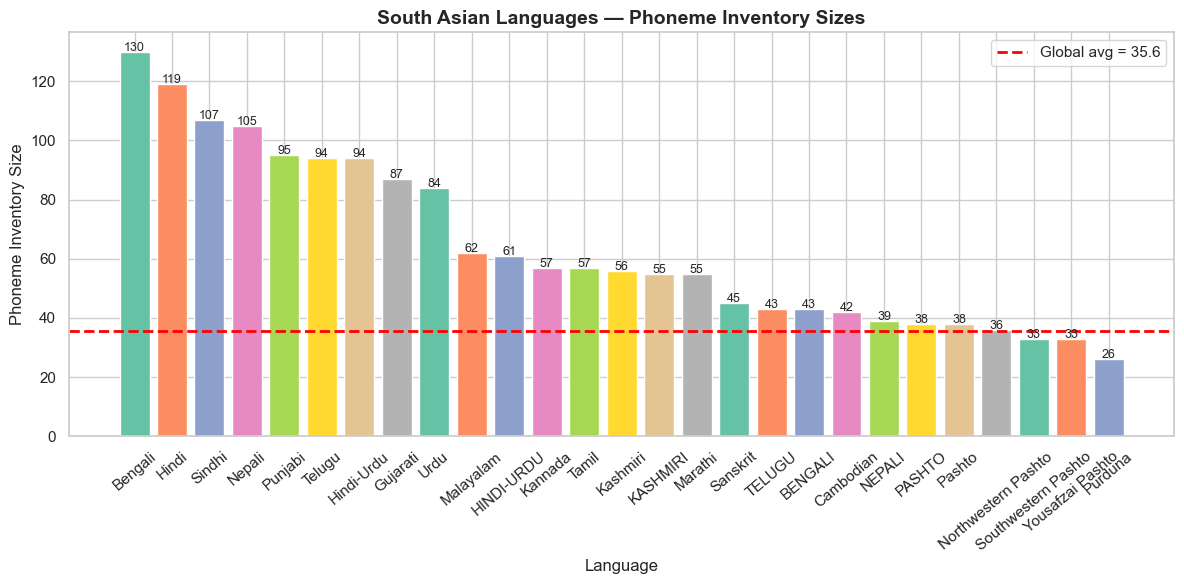


🔍 Most common phonemes among South Asian languages:
Phoneme
m     27
ɡ     25
j     25
ɖ     25
b     25
k     24
s     24
p     24
d̪    24
kʰ    23
pʰ    23
ʈ     23
ʈʰ    22
t̪    22
a     22
w     21
n     21
i     20
h     20
u     20
Name: LanguageName, dtype: int64


In [27]:
# ── South Asian / Indian Subcontinent languages ──────────────────────────────
south_asian_keywords = [
    'Hindi', 'Urdu', 'Bengali', 'Sanskrit', 'Tamil', 'Telugu', 'Marathi',
    'Gujarati', 'Punjabi', 'Kannada', 'Malayalam', 'Odia', 'Nepali',
    'Sinhala', 'Pashto', 'Sindhi', 'Kashmiri'
]

pattern = '|'.join(south_asian_keywords)
sa_df = df[df['LanguageName'].str.contains(pattern, case=False, na=False)]

if len(sa_df) > 0:
    sa_inventory = (
        sa_df.groupby('LanguageName')['Phoneme']
        .nunique()
        .sort_values(ascending=False)
        .reset_index()
    )
    sa_inventory.columns = ['Language', 'Inventory_Size']

    print(f'Found {len(sa_inventory)} South Asian languages in PHOIBLE')
    print(sa_inventory.to_string(index=False))

    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = sns.color_palette('Set2', len(sa_inventory))
    bars = ax.bar(sa_inventory['Language'], sa_inventory['Inventory_Size'],
                  color=colors, edgecolor='white')

    # Global average line
    global_avg = inventory_size['Inventory_Size'].mean()
    ax.axhline(global_avg, color='red', linestyle='--', linewidth=2,
               label=f'Global avg = {global_avg:.1f}')

    for bar, val in zip(bars, sa_inventory['Inventory_Size']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', fontsize=9)

    ax.set_xlabel('Language')
    ax.set_ylabel('Phoneme Inventory Size')
    ax.set_title('South Asian Languages — Phoneme Inventory Sizes', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=40)
    ax.legend()
    plt.tight_layout()
    plt.savefig('south_asian_languages.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Common phonemes across SA languages
    print('\n🔍 Most common phonemes among South Asian languages:')
    sa_phoneme_freq = (
        sa_df.groupby('Phoneme')['LanguageName']
        .nunique()
        .sort_values(ascending=False)
        .head(20)
    )
    print(sa_phoneme_freq)
else:
    print('No South Asian languages found — check language name spellings in your dataset.')

## 12. Phoneme Heatmap — Top Languages vs Top Phonemes

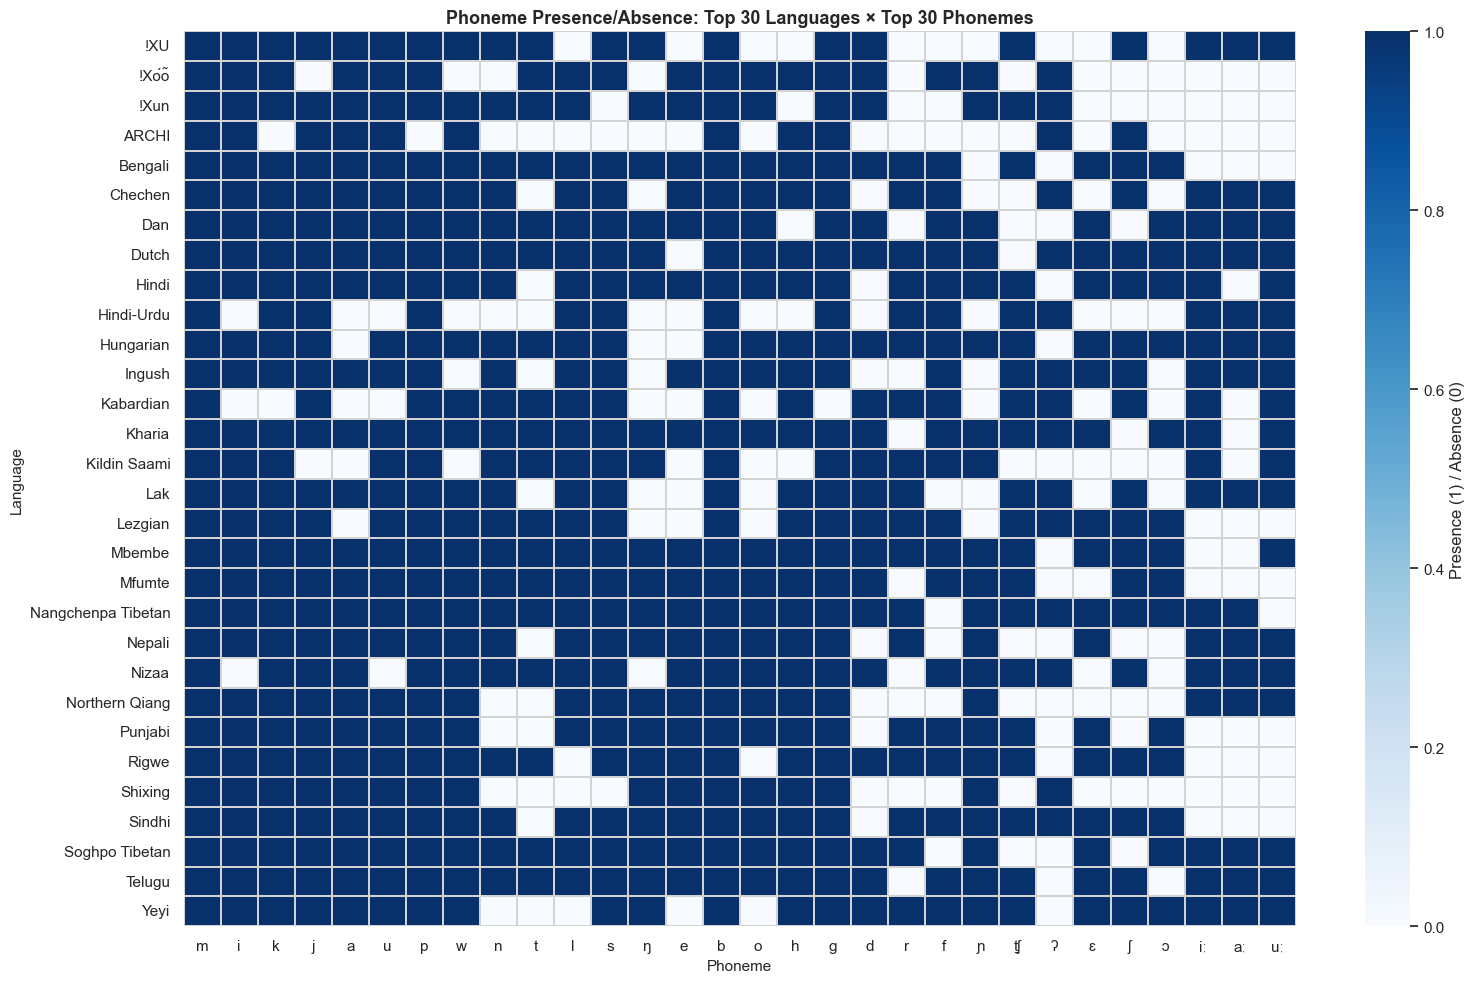

In [28]:
# ── Presence/absence heatmap for top 30 phonemes x 30 languages ──────────────
top30_phonemes = phoneme_freq.head(30)['Phoneme'].tolist()

# Pick 30 languages with largest inventories
top30_langs = inventory_size.nlargest(30, 'Inventory_Size')['Language'].tolist()

df_heatmap = df[
    df['LanguageName'].isin(top30_langs) &
    df['Phoneme'].isin(top30_phonemes)
]

heatmap_pivot = df_heatmap.pivot_table(
    index='LanguageName', columns='Phoneme',
    aggfunc='size', fill_value=0
)
heatmap_pivot = (heatmap_pivot > 0).astype(int)
# Reindex to ensure all columns
heatmap_pivot = heatmap_pivot.reindex(columns=top30_phonemes, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(heatmap_pivot, cmap='Blues', linewidths=0.3, linecolor='lightgray',
            cbar_kws={'label': 'Presence (1) / Absence (0)'},
            ax=ax, annot=False)
ax.set_title('Phoneme Presence/Absence: Top 30 Languages × Top 30 Phonemes',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Phoneme', fontsize=11)
ax.set_ylabel('Language', fontsize=11)
plt.tight_layout()
plt.savefig('phoneme_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Feature matrix shape: (2716, 50)


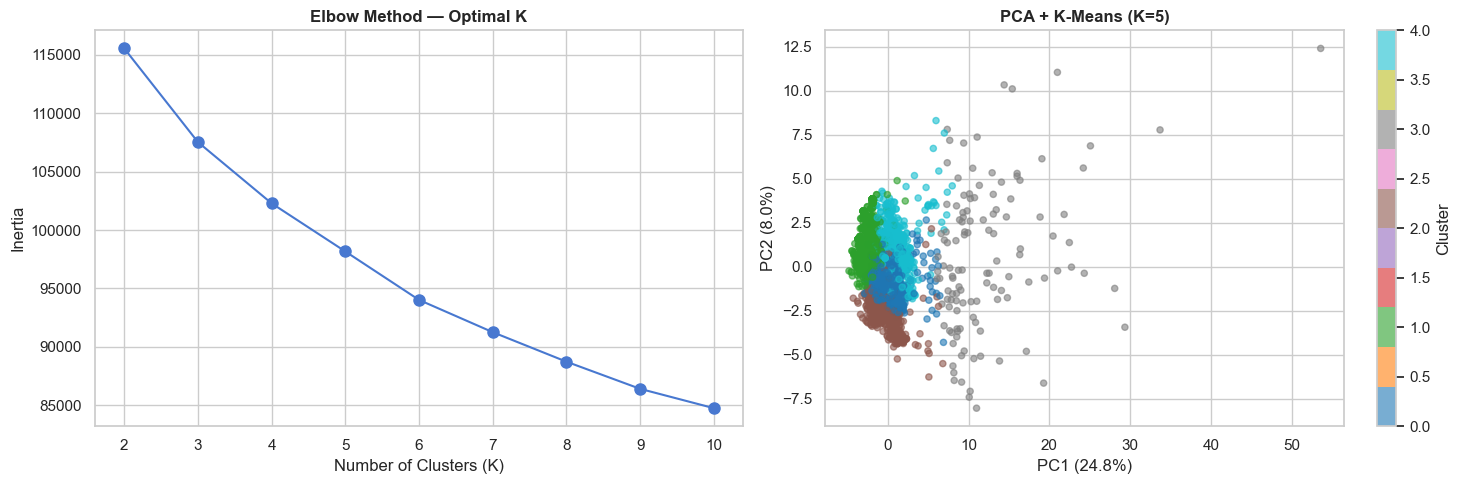


Cluster sizes:
0    893
1    834
2    389
3    120
4    480
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Top 50 most common phonemes as features
top_phonemes = phoneme_freq.head(50)['Phoneme'].tolist()
df_filtered  = df[df['Phoneme'].isin(top_phonemes)]


pivot = pd.crosstab(df_filtered['LanguageName'], df_filtered['Phoneme'])
# Fill missing phonemes with 0
pivot = pivot.reindex(columns=top_phonemes, fill_value=0)

print(f'Feature matrix shape: {pivot.shape}')

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(pivot)

# Elbow method
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xticks(list(K_range))

# PCA + K=5
K_FINAL  = 5
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
clusters = km_final.fit_predict(X)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                          c=clusters, cmap='tab10', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title(f'PCA + K-Means (K={K_FINAL})', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('language_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

pivot['Cluster'] = clusters
print('\nCluster sizes:')
print(pd.Series(clusters).value_counts().sort_index())

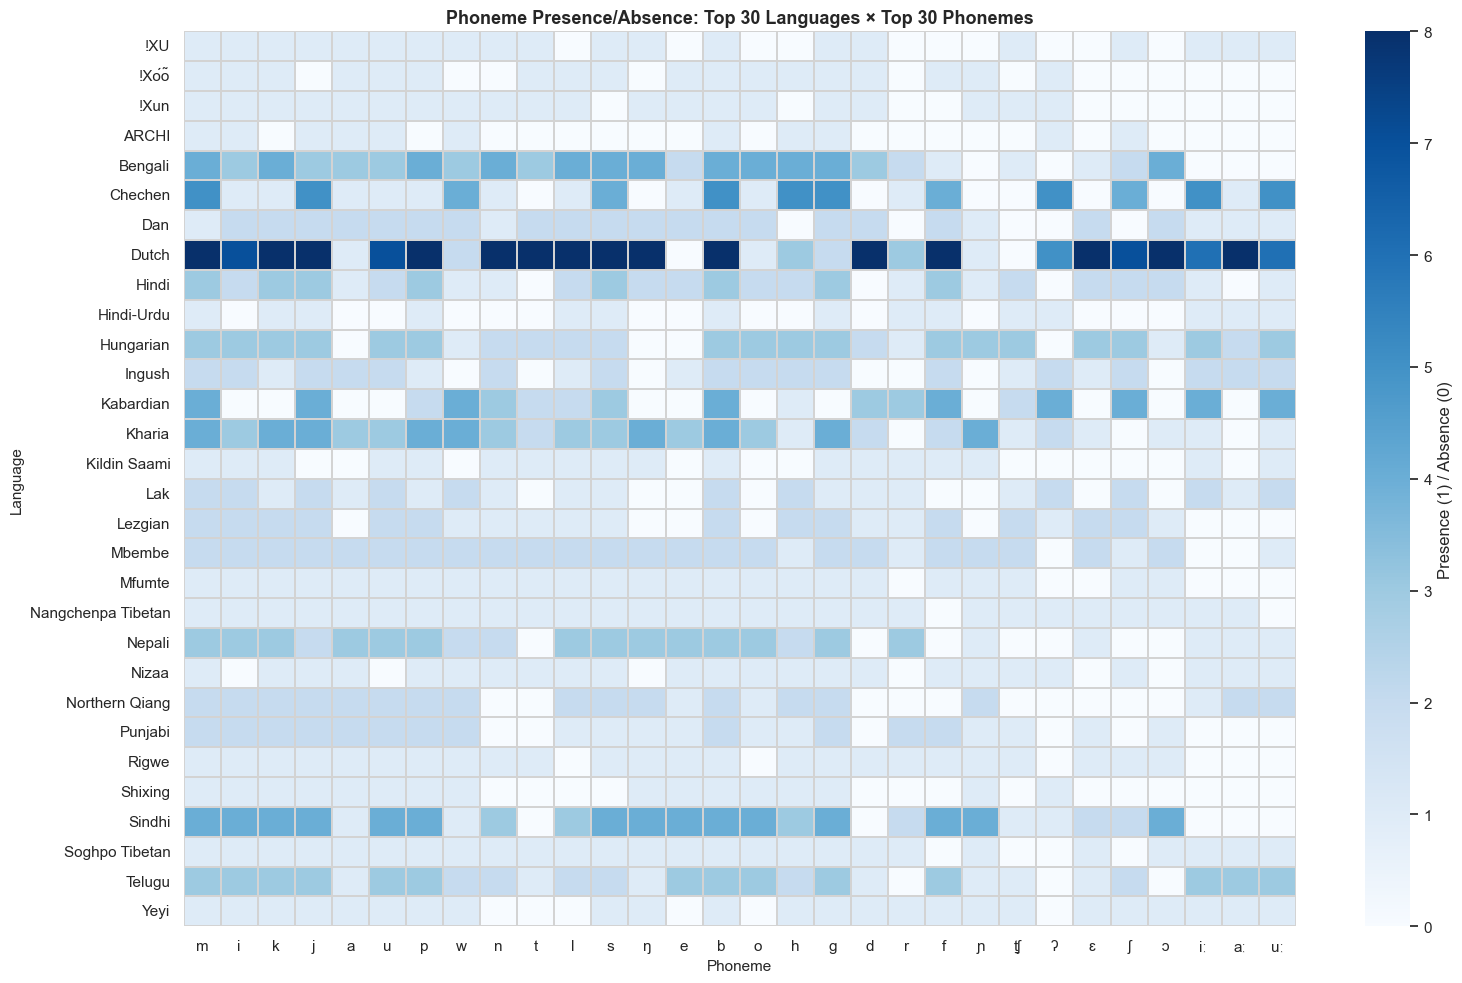

In [ ]:
top30_phonemes = phoneme_freq.head(30)['Phoneme'].tolist()
top30_langs    = inventory_size.nlargest(30, 'Inventory_Size')['Language'].tolist()

df_heatmap = df[
    df['LanguageName'].isin(top30_langs) &
    df['Phoneme'].isin(top30_phonemes)
]


heatmap_pivot = pd.crosstab(df_heatmap['LanguageName'], df_heatmap['Phoneme'])
heatmap_pivot = heatmap_pivot.reindex(columns=top30_phonemes, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(heatmap_pivot, cmap='Blues', linewidths=0.3, linecolor='lightgray',
            cbar_kws={'label': 'Presence (1) / Absence (0)'},
            ax=ax, annot=False)
ax.set_title('Phoneme Presence/Absence: Top 30 Languages × Top 30 Phonemes',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Phoneme', fontsize=11)
ax.set_ylabel('Language', fontsize=11)
plt.tight_layout()
plt.savefig('phoneme_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Key Insights & Conclusions

In [33]:
# ── Summary statistics ────────────────────────────────────────────────────────
print('=' * 60)
print('   📊 PHONEME DISTRIBUTION — KEY FINDINGS')
print('=' * 60)

print(f"""
📌 Dataset:
   Total languages analyzed : {total_languages:,}
   Total unique phonemes    : {phoneme_freq_full.shape[0]:,}

📌 Inventory Size:
   Average inventory size   : {inventory_size['Inventory_Size'].mean():.1f} phonemes
   Smallest inventory       : {inventory_size['Inventory_Size'].min()} phonemes
   Largest inventory        : {inventory_size['Inventory_Size'].max()} phonemes

📌 Universal Phonemes (>90% languages):
   {phoneme_freq[phoneme_freq['Percentage'] >= 90]['Phoneme'].tolist()}

📌 Rarity:
   Ultra-rare phonemes (<1% languages) : {(phoneme_freq_full['Pct'] < 1).sum():,}
   Universal phonemes (>50% languages) : {(phoneme_freq_full['Pct'] > 50).sum():,}
""")



   📊 PHONEME DISTRIBUTION — KEY FINDINGS

📌 Dataset:
   Total languages analyzed : 2,716
   Total unique phonemes    : 3,142

📌 Inventory Size:
   Average inventory size   : 35.6 phonemes
   Smallest inventory       : 11 phonemes
   Largest inventory        : 161 phonemes

📌 Universal Phonemes (>90% languages):
   ['m', 'i', 'k', 'j']

📌 Rarity:
   Ultra-rare phonemes (<1% languages) : 2,839
   Universal phonemes (>50% languages) : 18

